# WiDS Datathon 2026 — Feature Engineering & Modeling

**Strategy:** Modular survival analysis ensemble — CoxPH + Random Survival Forest + Gradient Boosting Survival  
**Metric:** `0.3 × C-index + 0.7 × (1 − Weighted Brier Score)`  
where Weighted Brier = `0.3 × Brier@24h + 0.4 × Brier@48h + 0.3 × Brier@72h`

---
**How to use this notebook:**
- Toggle models on/off in `MODEL_REGISTRY` (Section 0)
- Change model hyperparameters in `MODEL_REGISTRY`
- Toggle engineered features in `FEATURE_CONFIG` (Section 1)
- Change ensemble weights in `ENSEMBLE_CONFIG` (Section 5)
- Run all cells sequentially; Section 4 shows per-model scores before ensembling

## 0. Configuration — Edit Here First

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats

from lifelines import CoxPHFitter
from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42
DATA_DIR = 'Data/'
HORIZONS = [12, 24, 48, 72]          # submission horizons (hours)
BRIER_HORIZONS = [24, 48, 72]        # metric only uses these 3
BRIER_WEIGHTS  = {24: 0.3, 48: 0.4, 72: 0.3}

In [3]:
# ─────────────────────────────────────────────────────────────────
#  MODEL REGISTRY  ← set 'enabled': False to exclude from ensemble
# ─────────────────────────────────────────────────────────────────
MODEL_REGISTRY = {

    'CoxPH': {
        'enabled': True,
        'params': {
            'penalizer': 0.1,   # L2 regularisation strength (try 0.01–1.0)
            'l1_ratio':  0.05,  # 0 = pure L2, 1 = pure L1
        },
    },

    'RSF': {
        'enabled': True,
        'params': {
            'n_estimators':    300,
            'min_samples_leaf': 10,  # increase if overfitting
            'max_features':   'sqrt',
            'n_jobs':          -1,
            'random_state':    SEED,
        },
    },

    'GBT': {
        'enabled': True,
        'params': {
            'n_estimators':   200,
            'learning_rate':  0.05,
            'max_depth':        3,
            'subsample':       0.8,
            'min_samples_leaf': 8,
            'random_state':   SEED,
        },
    },

}

# ─────────────────────────────────────────────────────────────────
#  ENSEMBLE CONFIG  ← 'auto' uses CV hybrid scores as weights
#                     'uniform' weights all enabled models equally
#                     'manual' uses MANUAL_WEIGHTS below
# ─────────────────────────────────────────────────────────────────
ENSEMBLE_CONFIG = {
    'weight_mode': 'auto',    # 'auto' | 'uniform' | 'manual'
    'manual_weights': {
        'CoxPH': 0.25,
        'RSF':   0.50,
        'GBT':   0.25,
    },
}

# ─────────────────────────────────────────────────────────────────
#  FEATURE CONFIG  ← toggle engineered features and drop lists
# ─────────────────────────────────────────────────────────────────
FEATURE_CONFIG = {
    # Step 1: near-duplicate drops (confirmed by EDA, r > 0.97)
    'drop_redundant': [
        'relative_growth_0_5h',      # exact duplicate of area_growth_rel_0_5h (r=1.000)
        'area_growth_rate_ha_per_h', # r=0.991 with area_growth_abs_0_5h
        'centroid_displacement_m',   # r=0.989 with radial_growth_m
        'centroid_speed_m_per_h',    # r=0.989 with radial_growth_rate_m_per_h
        'closing_speed_m_per_h',     # cluster with dist_change_ci_0_5h (r>0.99)
        'projected_advance_m',       # cluster with dist_change_ci_0_5h (r>0.99)
        'dist_slope_ci_0_5h',        # cluster with dist_change_ci_0_5h (r>0.99)
        'closing_speed_abs_m_per_h', # r=0.997 with dist_std_ci_0_5h
    ],

    # Step 2: non-significant noise drops (MW p > 0.05, MI ≈ 0)
    'drop_noise': [
        'event_start_hour',
        'event_start_dayofweek',
        'event_start_month',
        'along_track_speed',
        'cross_track_component',
        'dist_accel_m_per_h2',
    ],

    # Step 3: engineered features (set False to disable individually)
    'add_log1p_dist_min':    True,   # r=-0.81 with event vs -0.48 raw
    'add_dist_under_5km':    True,   # binary flag: 100% event rate when True
    'add_is_growing':        True,   # growing 72% vs static 26% event rate
    'add_speed_x_alignment': True,   # radial_growth_rate * alignment_abs, p=0.003
    'add_tti_proxy':         False,  # dist_min / closing_speed: 92% zeros, use with care
}

print('Configuration loaded.')
print(f'Enabled models: {[k for k,v in MODEL_REGISTRY.items() if v["enabled"]]}')

Configuration loaded.
Enabled models: ['CoxPH', 'RSF', 'GBT']


## 1. Data Loading & Feature Engineering

In [4]:
train_raw = pd.read_csv(DATA_DIR + 'train.csv')
test_raw  = pd.read_csv(DATA_DIR + 'test.csv')

print(f'Train raw: {train_raw.shape}  |  Test raw: {test_raw.shape}')

Train raw: (221, 37)  |  Test raw: (95, 35)


In [5]:
def engineer_features(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Apply all feature engineering steps. Operates on a copy."""
    df = df.copy()
    EPS = 1e-6

    if cfg['add_log1p_dist_min']:
        df['log1p_dist_min'] = np.log1p(df['dist_min_ci_0_5h'])

    if cfg['add_dist_under_5km']:
        df['dist_under_5km'] = (df['dist_min_ci_0_5h'] < 5000).astype(int)

    if cfg['add_is_growing']:
        df['is_growing'] = (df['area_growth_abs_0_5h'] > 0).astype(int)

    if cfg['add_speed_x_alignment']:
        df['speed_x_alignment'] = df['radial_growth_rate_m_per_h'] * df['alignment_abs']

    if cfg['add_tti_proxy']:
        df['tti_proxy'] = np.log1p(
            df['dist_min_ci_0_5h'] / (df['closing_speed_abs_m_per_h'].clip(lower=0) + EPS)
        )

    return df


def select_features(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Drop redundant and noise features per FEATURE_CONFIG."""
    to_drop = cfg['drop_redundant'] + cfg['drop_noise']
    # Only drop columns that actually exist (safe if user removed from config)
    to_drop = [c for c in to_drop if c in df.columns]
    return df.drop(columns=to_drop)


def build_feature_matrix(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Full pipeline: engineer → select → return feature-only DataFrame."""
    df = engineer_features(df, cfg)
    df = select_features(df, cfg)
    drop_meta = [c for c in ['event_id', 'time_to_hit_hours', 'event'] if c in df.columns]
    return df.drop(columns=drop_meta)


X_train = build_feature_matrix(train_raw, FEATURE_CONFIG)
X_test  = build_feature_matrix(test_raw,  FEATURE_CONFIG)
y_time  = train_raw['time_to_hit_hours'].values
y_event = train_raw['event'].values.astype(bool)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'\nFinal features ({X_train.shape[1]}):')
print(X_train.columns.tolist())

X_train: (221, 24)  |  X_test: (95, 24)

Final features (24):
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'log1p_dist_min', 'dist_under_5km', 'is_growing', 'speed_x_alignment']


In [6]:
# Quick sanity check: no nulls, no inf
assert X_train.isnull().sum().sum() == 0, 'NaNs in X_train!'
assert X_test.isnull().sum().sum()  == 0, 'NaNs in X_test!'
assert np.isfinite(X_train.values).all(), 'Inf in X_train!'
assert np.isfinite(X_test.values).all(),  'Inf in X_test!'
print('Sanity checks passed — no NaNs or Infs.')

Sanity checks passed — no NaNs or Infs.


## 2. Metric Implementation

In [7]:
def brier_at_horizon(y_event: np.ndarray, y_time: np.ndarray,
                     y_pred_prob: np.ndarray, H: float) -> float:
    """
    Competition Brier score at a single horizon H.

    Rules (from competition page):
      - event=1, time <= H  -> y_obs = 1
      - event=1, time >  H  -> y_obs = 0
      - event=0, time >= H  -> y_obs = 0  (observed past H, survived)
      - event=0, time <  H  -> EXCLUDED    (censored before outcome known)
    """
    exclude = (y_event == 0) & (y_time < H)
    mask = ~exclude
    y_obs = ((y_event == 1) & (y_time <= H)).astype(float)
    return float(np.mean((y_obs[mask] - y_pred_prob[mask]) ** 2))


def weighted_brier(y_event: np.ndarray, y_time: np.ndarray,
                   prob_dict: dict) -> float:
    """
    Weighted Brier Score = 0.3*Brier@24 + 0.4*Brier@48 + 0.3*Brier@72

    prob_dict: {12: array, 24: array, 48: array, 72: array}
    """
    return sum(
        w * brier_at_horizon(y_event, y_time, prob_dict[H], H)
        for H, w in BRIER_WEIGHTS.items()
    )


def compute_cindex(y_event: np.ndarray, y_time: np.ndarray,
                   risk_scores: np.ndarray) -> float:
    """
    C-index via sksurv (handles ties correctly).
    risk_scores: higher = more risk = shorter survival expected.
    """
    return concordance_index_censored(y_event.astype(bool), y_time, risk_scores)[0]


def compute_hybrid_score(cindex: float, wbrier: float) -> float:
    """0.3 × C-index + 0.7 × (1 − Weighted Brier)"""
    return 0.3 * cindex + 0.7 * (1.0 - wbrier)


def evaluate_predictions(y_event, y_time, prob_dict, label=''):
    """
    Full evaluation: per-horizon Brier + weighted Brier + C-index + hybrid score.
    risk_scores derived from 1 - S(24h) (higher prob_24h = more risk).
    """
    risk = prob_dict[24]  # P(hit by 24h) as risk proxy
    ci   = compute_cindex(y_event, y_time, risk)
    wb   = weighted_brier(y_event, y_time, prob_dict)
    hs   = compute_hybrid_score(ci, wb)

    b_per_h = {H: brier_at_horizon(y_event, y_time, prob_dict[H], H) for H in HORIZONS}

    row = {'Model': label,
           'C-index': ci,
           'Brier@12': b_per_h[12],
           'Brier@24': b_per_h[24],
           'Brier@48': b_per_h[48],
           'Brier@72': b_per_h[72],
           'Weighted Brier': wb,
           'Hybrid Score': hs}
    return row


print('Metric functions defined.')

Metric functions defined.


## 3. Model Wrappers
Each wrapper exposes a consistent interface:
- `fit(X_df, y_event, y_time)`
- `predict_survival_probs(X_df)` → dict `{12: array, 24: array, 48: array, 72: array}` of P(hit by H)
- `get_risk_scores(X_df)` → 1-D array (higher = more dangerous fire)

In [8]:
class CoxPHWrapper:
    """Regularised Cox Proportional Hazards via lifelines."""

    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer
        self.l1_ratio  = l1_ratio
        self.model     = None
        self.scaler    = StandardScaler()

    def fit(self, X: pd.DataFrame, y_event: np.ndarray, y_time: np.ndarray):
        X_scaled = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        df_fit = X_scaled.copy()
        df_fit['duration'] = y_time
        df_fit['event']    = y_event.astype(int)
        self.model = CoxPHFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(df_fit, duration_col='duration', event_col='event')
        return self

    def _survival_at_times(self, X: pd.DataFrame) -> np.ndarray:
        """Returns array (n_samples, n_horizons) of S(t) values."""
        X_scaled = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        surv_df  = self.model.predict_survival_function(X_scaled, times=HORIZONS)
        # lifelines returns shape (n_times, n_samples)
        return surv_df.values.T  # → (n_samples, n_times)

    def predict_survival_probs(self, X: pd.DataFrame) -> dict:
        S = self._survival_at_times(X)
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X: pd.DataFrame) -> np.ndarray:
        X_scaled = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        return self.model.predict_partial_hazard(X_scaled).values

    def get_feature_importance(self) -> pd.Series:
        """Returns coefficients (hazard ratios on log scale)."""
        return self.model.params_.sort_values(key=abs, ascending=False)


print('CoxPHWrapper defined.')

CoxPHWrapper defined.


In [9]:
def _eval_step_fn_safe(fn, t):
    """Evaluate a sksurv StepFunction at time t; extrapolate flat beyond range."""
    t_clamped = float(np.clip(t, fn.x[0], fn.x[-1]))
    return float(fn(t_clamped))


class RSFWrapper:
    """Random Survival Forest via scikit-survival."""

    def __init__(self, **params):
        self.model = RandomSurvivalForest(**params)

    def fit(self, X: pd.DataFrame, y_event: np.ndarray, y_time: np.ndarray):
        y_struct = Surv.from_arrays(y_event.astype(bool), y_time)
        self.model.fit(X.values, y_struct)
        return self

    def predict_survival_probs(self, X: pd.DataFrame) -> dict:
        surv_fns = self.model.predict_survival_function(X.values)
        S = np.array([[_eval_step_fn_safe(fn, t) for t in HORIZONS]
                      for fn in surv_fns])  # (n_samples, n_horizons)
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X: pd.DataFrame) -> np.ndarray:
        return self.model.predict(X.values)  # cumulative hazard = risk score

    def get_feature_importance(self) -> pd.Series:
        """Permutation importance on training data (RSF has no feature_importances_)."""
        from sklearn.inspection import permutation_importance
        cols = X_train.columns
        y_struct = Surv.from_arrays(y_event.astype(bool), y_time)
        result = permutation_importance(
            self.model, X_train.values, y_struct,
            n_repeats=5, random_state=SEED, n_jobs=-1
        )
        return pd.Series(result.importances_mean, index=cols).sort_values(ascending=False)


print('RSFWrapper defined.')

RSFWrapper defined.


In [10]:
class GBTWrapper:
    """Gradient Boosting Survival Analysis via scikit-survival."""

    def __init__(self, **params):
        self.model = GradientBoostingSurvivalAnalysis(**params)

    def fit(self, X: pd.DataFrame, y_event: np.ndarray, y_time: np.ndarray):
        y_struct = Surv.from_arrays(y_event.astype(bool), y_time)
        self.model.fit(X.values, y_struct)
        return self

    def predict_survival_probs(self, X: pd.DataFrame) -> dict:
        surv_fns = self.model.predict_survival_function(X.values)
        S = np.array([[_eval_step_fn_safe(fn, t) for t in HORIZONS]
                      for fn in surv_fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X: pd.DataFrame) -> np.ndarray:
        return self.model.predict(X.values)

    def get_feature_importance(self) -> pd.Series:
        cols = X_train.columns
        return pd.Series(self.model.feature_importances_, index=cols).sort_values(ascending=False)


print('GBTWrapper defined.')

GBTWrapper defined.


In [11]:
# Factory: build a wrapper from MODEL_REGISTRY entry
def build_model(name: str) -> object:
    cfg = MODEL_REGISTRY[name]
    p   = cfg['params']
    if name == 'CoxPH':
        return CoxPHWrapper(**p)
    elif name == 'RSF':
        return RSFWrapper(**p)
    elif name == 'GBT':
        return GBTWrapper(**p)
    else:
        raise ValueError(f'Unknown model: {name}. Add a wrapper class and update build_model().')

print('build_model() factory ready.')

build_model() factory ready.


## 4. Cross-Validation & Per-Model Evaluation

In [12]:
def cross_validate_model(name: str, X: pd.DataFrame,
                         y_event: np.ndarray, y_time: np.ndarray,
                         n_splits: int = 5, verbose: bool = True) -> pd.DataFrame:
    """
    Stratified K-fold CV. Returns a DataFrame with one row per fold
    plus a 'MEAN' summary row.
    """
    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y_event), 1):
        X_tr,  X_val  = X.iloc[tr_idx],   X.iloc[val_idx]
        ye_tr, ye_val = y_event[tr_idx],   y_event[val_idx]
        yt_tr, yt_val = y_time[tr_idx],    y_time[val_idx]

        model = build_model(name)
        model.fit(X_tr, ye_tr, yt_tr)
        prob_dict = model.predict_survival_probs(X_val)

        row = evaluate_predictions(ye_val, yt_val, prob_dict, label=f'{name} fold-{fold}')
        row['Fold'] = fold
        rows.append(row)

        if verbose:
            print(f'  Fold {fold}: C-index={row["C-index"]:.4f}  '
                  f'WBrier={row["Weighted Brier"]:.4f}  '
                  f'Hybrid={row["Hybrid Score"]:.4f}')

    result_df = pd.DataFrame(rows)
    numeric_cols = ['C-index','Brier@12','Brier@24','Brier@48','Brier@72','Weighted Brier','Hybrid Score']
    mean_row = result_df[numeric_cols].mean().to_dict()
    mean_row['Model'] = f'{name} MEAN'
    mean_row['Fold']  = 'MEAN'
    result_df = pd.concat([result_df, pd.DataFrame([mean_row])], ignore_index=True)

    return result_df


print('cross_validate_model() defined.')

cross_validate_model() defined.


In [13]:
# ── Run CV for all enabled models ──
# Results stored in CV_RESULTS dict; scores in MODEL_SCORES for comparison

CV_RESULTS  = {}  # name -> full fold DataFrame
MODEL_SCORES = []  # list of mean-row dicts for the comparison table

enabled_models = [k for k, v in MODEL_REGISTRY.items() if v['enabled']]

for model_name in enabled_models:
    print(f'\n{'='*55}')
    print(f'  {model_name} — 5-fold CV')
    print(f'{'='*55}')
    cv_df = cross_validate_model(model_name, X_train, y_event, y_time, n_splits=5)
    CV_RESULTS[model_name] = cv_df
    mean_row = cv_df[cv_df['Fold'] == 'MEAN'].iloc[0].to_dict()
    mean_row['Model'] = model_name
    MODEL_SCORES.append(mean_row)

print('\nCV complete.')


  CoxPH — 5-fold CV
  Fold 1: C-index=0.9491  WBrier=0.0279  Hybrid=0.9652
  Fold 2: C-index=0.9417  WBrier=0.0340  Hybrid=0.9587
  Fold 3: C-index=0.9252  WBrier=0.0386  Hybrid=0.9505
  Fold 4: C-index=0.9615  WBrier=0.0085  Hybrid=0.9825
  Fold 5: C-index=0.9434  WBrier=0.0160  Hybrid=0.9718

  RSF — 5-fold CV
  Fold 1: C-index=0.9491  WBrier=0.0135  Hybrid=0.9753
  Fold 2: C-index=0.9439  WBrier=0.0319  Hybrid=0.9609
  Fold 3: C-index=0.8964  WBrier=0.0416  Hybrid=0.9398
  Fold 4: C-index=0.9655  WBrier=0.0140  Hybrid=0.9798
  Fold 5: C-index=0.9560  WBrier=0.0260  Hybrid=0.9686

  GBT — 5-fold CV
  Fold 1: C-index=0.9579  WBrier=0.0017  Hybrid=0.9862
  Fold 2: C-index=0.9406  WBrier=0.0232  Hybrid=0.9659
  Fold 3: C-index=0.9391  WBrier=0.0358  Hybrid=0.9567
  Fold 4: C-index=0.9686  WBrier=0.0026  Hybrid=0.9887
  Fold 5: C-index=0.9413  WBrier=0.0144  Hybrid=0.9723

CV complete.


In [14]:
# ── Model comparison table ──
comparison_df = pd.DataFrame(MODEL_SCORES).set_index('Model')
score_cols = ['C-index','Brier@12','Brier@24','Brier@48','Brier@72','Weighted Brier','Hybrid Score']

# Highlight best in each column
def highlight_best(s):
    # For Brier scores: lower is better; for C-index & Hybrid: higher is better
    lower_better = s.name in ['Brier@12','Brier@24','Brier@48','Brier@72','Weighted Brier']
    if lower_better:
        best = s == s.min()
    else:
        best = s == s.max()
    return ['background-color: #d4efdf; font-weight: bold' if v else '' for v in best]

print('=== MODEL COMPARISON (5-fold CV mean scores) ===')
comparison_df[score_cols].style.apply(highlight_best)

=== MODEL COMPARISON (5-fold CV mean scores) ===


,C-index,Brier@12,Brier@24,Brier@48,Brier@72,Weighted Brier,Hybrid Score
Model,,,,,,,
CoxPH,0.944179,0.056849,0.037283,0.027426,0.009511,0.025009,0.965748
RSF,0.942185,0.058341,0.036723,0.026516,0.012649,0.025418,0.964863
GBT,0.949494,0.051255,0.028242,0.016006,0.002251,0.015550,0.973963


In [15]:
# ── Per-fold breakdown for each model ──
for name in enabled_models:
    print(f'\n--- {name} fold-by-fold ---')
    fold_df = CV_RESULTS[name][['Fold','C-index','Weighted Brier','Hybrid Score']]
    print(fold_df.to_string(index=False))


--- CoxPH fold-by-fold ---
Fold  C-index  Weighted Brier  Hybrid Score
   1   0.9491          0.0279        0.9652
   2   0.9417          0.0340        0.9587
   3   0.9252          0.0386        0.9505
   4   0.9615          0.0085        0.9825
   5   0.9434          0.0160        0.9718
MEAN   0.9442          0.0250        0.9657

--- RSF fold-by-fold ---
Fold  C-index  Weighted Brier  Hybrid Score
   1   0.9491          0.0135        0.9753
   2   0.9439          0.0319        0.9609
   3   0.8964          0.0416        0.9398
   4   0.9655          0.0140        0.9798
   5   0.9560          0.0260        0.9686
MEAN   0.9422          0.0254        0.9649

--- GBT fold-by-fold ---
Fold  C-index  Weighted Brier  Hybrid Score
   1   0.9579          0.0017        0.9862
   2   0.9406          0.0232        0.9659
   3   0.9391          0.0358        0.9567
   4   0.9686          0.0026        0.9887
   5   0.9413          0.0144        0.9723
MEAN   0.9495          0.0156        0.9

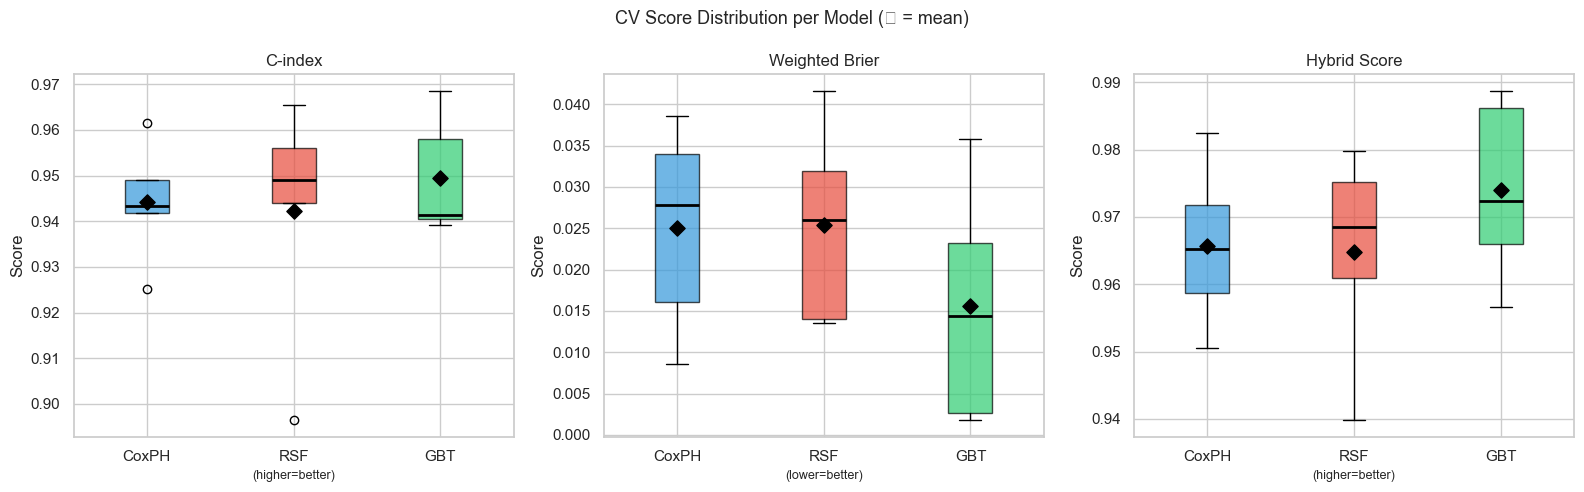

In [16]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['C-index', 'Weighted Brier', 'Hybrid Score']

for ax, metric in zip(axes, metrics):
    vals  = [CV_RESULTS[n][CV_RESULTS[n]['Fold'] != 'MEAN'][metric].values for n in enabled_models]
    means = [float(CV_RESULTS[n][CV_RESULTS[n]['Fold'] == 'MEAN'][metric].iloc[0]) for n in enabled_models]

    bp = ax.boxplot(vals, labels=enabled_models, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, (m, name) in enumerate(zip(means, enabled_models), 1):
        ax.scatter(i, m, color='black', zorder=5, s=60, marker='D')

    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score')
    note = '(higher=better)' if metric in ['C-index','Hybrid Score'] else '(lower=better)'
    ax.set_xlabel(note, fontsize=9)

plt.suptitle('CV Score Distribution per Model (◆ = mean)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Importance per Model

In [18]:
# Retrain each model on full training set to get feature importances
FITTED_MODELS = {}

for name in enabled_models:
    m = build_model(name)
    m.fit(X_train, y_event, y_time)
    FITTED_MODELS[name] = m
    print(f'{name}: fitted on full train set.')

print('\nAll models fitted.')

CoxPH: fitted on full train set.
RSF: fitted on full train set.
GBT: fitted on full train set.

All models fitted.


NotImplementedError: 

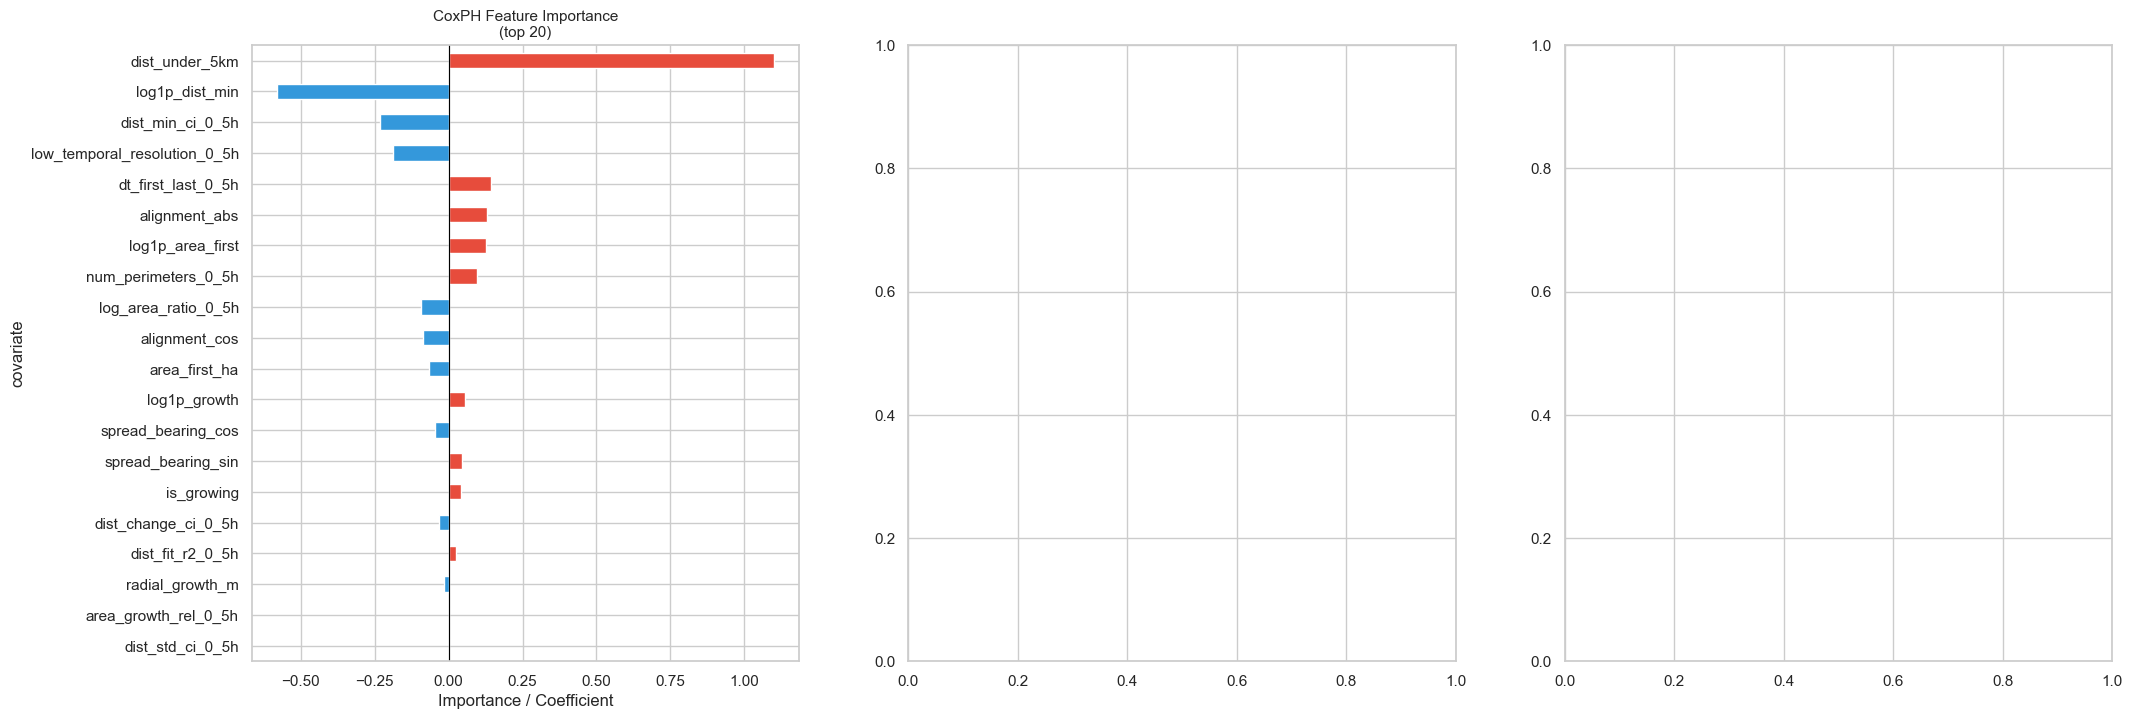

In [19]:
n_models = len(enabled_models)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 8))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, enabled_models):
    imp = FITTED_MODELS[name].get_feature_importance()
    top = imp.head(20)

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top.values]
    top.plot(kind='barh', ax=ax, color=colors)
    ax.invert_yaxis()
    ax.set_title(f'{name} Feature Importance\n(top 20)', fontsize=11)
    ax.set_xlabel('Importance / Coefficient')
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Feature Importance by Model', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Rank features: average rank across all enabled models
rank_dfs = []
for name in enabled_models:
    imp = FITTED_MODELS[name].get_feature_importance().abs()
    rank = imp.rank(ascending=False)
    rank_dfs.append(rank.rename(name))

rank_comparison = pd.concat(rank_dfs, axis=1)
rank_comparison['Mean Rank'] = rank_comparison.mean(axis=1)
rank_comparison = rank_comparison.sort_values('Mean Rank')

print('Feature ranking across models (rank 1 = most important):')
rank_comparison

## 6. Ensemble

Ensemble strategy: **weighted average of survival probabilities** from all enabled models.  
Weights can be set via `ENSEMBLE_CONFIG['weight_mode']` in Section 0.

In [ ]:
def compute_ensemble_weights(mode: str) -> dict:
    """
    Returns normalised weight dict for enabled models.
    mode: 'auto'    -> weights proportional to CV hybrid score
          'uniform' -> equal weights
          'manual'  -> use ENSEMBLE_CONFIG['manual_weights']
    """
    if mode == 'uniform':
        n = len(enabled_models)
        return {name: 1.0 / n for name in enabled_models}

    elif mode == 'auto':
        scores = {row['Model']: float(row['Hybrid Score'])
                  for row in MODEL_SCORES if row['Model'] in enabled_models}
        total  = sum(scores.values())
        return {name: scores[name] / total for name in enabled_models}

    elif mode == 'manual':
        raw  = {k: v for k, v in ENSEMBLE_CONFIG['manual_weights'].items()
                if k in enabled_models}
        total = sum(raw.values())
        return {k: v / total for k, v in raw.items()}

    else:
        raise ValueError(f'Unknown weight_mode: {mode}')


weights = compute_ensemble_weights(ENSEMBLE_CONFIG['weight_mode'])
print(f'Ensemble weights ({ENSEMBLE_CONFIG["weight_mode"]} mode):')
for name, w in weights.items():
    print(f'  {name}: {w:.4f}')

In [ ]:
def ensemble_predictions(fitted_models: dict, weights: dict,
                         X: pd.DataFrame) -> dict:
    """
    Weighted average of survival probabilities across models.
    Returns {H: array} of P(hit by H) for each horizon.
    Enforces monotonicity: prob_12h <= prob_24h <= prob_48h <= prob_72h.
    """
    combined = {H: np.zeros(len(X)) for H in HORIZONS}

    for name, w in weights.items():
        prob_dict = fitted_models[name].predict_survival_probs(X)
        for H in HORIZONS:
            combined[H] += w * prob_dict[H]

    # Clip to [0, 1] before monotonicity fix
    for H in HORIZONS:
        combined[H] = combined[H].clip(0, 1)

    # Enforce monotonicity: P(hit by H1) <= P(hit by H2) for H1 < H2
    prob_matrix = np.column_stack([combined[H] for H in HORIZONS])  # (n, 4)
    prob_matrix = np.maximum.accumulate(prob_matrix, axis=1)         # running max
    for i, H in enumerate(HORIZONS):
        combined[H] = prob_matrix[:, i]

    return combined


print('ensemble_predictions() defined (with monotonicity enforcement).')

In [ ]:
# ── CV evaluation of the ensemble ──
print('Running ensemble CV evaluation...')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
ensemble_rows = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_event), 1):
    X_tr,  X_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
    ye_tr, ye_val = y_event[tr_idx],        y_event[val_idx]
    yt_tr, yt_val = y_time[tr_idx],         y_time[val_idx]

    fold_models = {}
    for name in enabled_models:
        m = build_model(name)
        m.fit(X_tr, ye_tr, yt_tr)
        fold_models[name] = m

    # Recompute weights from MODEL_SCORES (global CV means)
    fold_weights = compute_ensemble_weights(ENSEMBLE_CONFIG['weight_mode'])
    prob_dict    = ensemble_predictions(fold_models, fold_weights, X_val)
    row          = evaluate_predictions(ye_val, yt_val, prob_dict, label=f'Ensemble fold-{fold}')
    row['Fold']  = fold
    ensemble_rows.append(row)
    print(f'  Fold {fold}: C-index={row["C-index"]:.4f}  '
          f'WBrier={row["Weighted Brier"]:.4f}  '
          f'Hybrid={row["Hybrid Score"]:.4f}')

ensemble_cv_df  = pd.DataFrame(ensemble_rows)
numeric_cols    = ['C-index','Brier@12','Brier@24','Brier@48','Brier@72','Weighted Brier','Hybrid Score']
ensemble_mean   = ensemble_cv_df[numeric_cols].mean()

print(f"\n  ENSEMBLE MEAN: C-index={ensemble_mean['C-index']:.4f}  "
      f"WBrier={ensemble_mean['Weighted Brier']:.4f}  "
      f"Hybrid={ensemble_mean['Hybrid Score']:.4f}")

In [ ]:
# ── Final comparison: individual models vs ensemble ──
all_score_rows = []

for row in MODEL_SCORES:
    all_score_rows.append({k: row[k] for k in ['Model'] + score_cols})

ens_row = ensemble_mean.to_dict()
ens_row['Model'] = 'ENSEMBLE'
all_score_rows.append(ens_row)

final_comparison = pd.DataFrame(all_score_rows).set_index('Model')

print('=== FINAL MODEL COMPARISON (5-fold CV mean) ===')
final_comparison[score_cols].style.apply(highlight_best)

## 7. Calibration Check

In [ ]:
def calibration_plot_data(y_event, y_time, prob_dict, H, n_bins=8):
    """Bin predictions and compute observed rates for a single horizon H."""
    pred = prob_dict[H]
    obs  = ((y_event == 1) & (y_time <= H)).astype(float)
    # Exclude fires censored before H
    mask = ~((y_event == 0) & (y_time < H))
    pred, obs = pred[mask], obs[mask]

    bins   = np.linspace(0, 1, n_bins + 1)
    bin_id = np.digitize(pred, bins) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    bin_pred, bin_obs, bin_n = [], [], []
    for b in range(n_bins):
        mask_b = bin_id == b
        if mask_b.sum() > 0:
            bin_pred.append(pred[mask_b].mean())
            bin_obs.append(obs[mask_b].mean())
            bin_n.append(mask_b.sum())
    return np.array(bin_pred), np.array(bin_obs), np.array(bin_n)


# Collect out-of-fold predictions for calibration plots
# Reuse the individual-model CV results conceptually; use ensemble CV predictions
oof_preds_by_model = {name: {H: np.zeros(len(X_train)) for H in HORIZONS}
                      for name in enabled_models}
oof_preds_by_model['ENSEMBLE'] = {H: np.zeros(len(X_train)) for H in HORIZONS}

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for tr_idx, val_idx in skf2.split(X_train, y_event):
    X_tr,  X_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
    ye_tr, yt_tr  = y_event[tr_idx],        y_time[tr_idx]

    fold_m = {}
    for name in enabled_models:
        m = build_model(name)
        m.fit(X_tr, ye_tr, yt_tr)
        fold_m[name] = m
        pd_val = m.predict_survival_probs(X_val)
        for H in HORIZONS:
            oof_preds_by_model[name][H][val_idx] = pd_val[H]

    ens_pd = ensemble_predictions(fold_m, compute_ensemble_weights(ENSEMBLE_CONFIG['weight_mode']), X_val)
    for H in HORIZONS:
        oof_preds_by_model['ENSEMBLE'][H][val_idx] = ens_pd[H]

print('OOF predictions collected.')

In [ ]:
plot_models = enabled_models + ['ENSEMBLE']
plot_horizons = [24, 48, 72]

fig, axes = plt.subplots(len(plot_models), 3,
                         figsize=(14, 4 * len(plot_models)))
if len(plot_models) == 1:
    axes = axes[np.newaxis, :]

for r, name in enumerate(plot_models):
    for c, H in enumerate(plot_horizons):
        ax = axes[r, c]
        bp, bo, bn = calibration_plot_data(
            y_event, y_time, oof_preds_by_model[name], H)

        sc = ax.scatter(bp, bo, s=bn * 5, alpha=0.8,
                        color='#2980b9' if name != 'ENSEMBLE' else '#e74c3c',
                        edgecolors='black', linewidths=0.5)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Mean predicted prob')
        ax.set_ylabel('Observed rate')
        title_col = 'blue' if name != 'ENSEMBLE' else 'red'
        ax.set_title(f'{name} @ {H}h', fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Calibration Curves (OOF predictions, bubble size ∝ n fires per bin)',
             fontsize=12)
plt.tight_layout()
plt.show()

## 8. Final Predictions & Submission

In [ ]:
# Retrain all enabled models on the FULL training set
FINAL_MODELS = {}
for name in enabled_models:
    m = build_model(name)
    m.fit(X_train, y_event, y_time)
    FINAL_MODELS[name] = m
    print(f'{name}: fitted on full train.')

final_weights = compute_ensemble_weights(ENSEMBLE_CONFIG['weight_mode'])
test_probs = ensemble_predictions(FINAL_MODELS, final_weights, X_test)

print('\nTest predictions generated.')
print('Mean predicted probabilities on test set:')
for H in HORIZONS:
    print(f'  P(hit by {H}h): mean={test_probs[H].mean():.4f}, '
          f'min={test_probs[H].min():.4f}, max={test_probs[H].max():.4f}')

In [ ]:
# ── Verify monotonicity ──
for i in range(len(test_probs[12])):
    p = [test_probs[H][i] for H in HORIZONS]
    assert p == sorted(p), f'Monotonicity violated at row {i}: {p}'
print('Monotonicity check passed for all test rows.')

In [ ]:
# ── Build submission file ──
submission = pd.DataFrame({
    'event_id': test_raw['event_id'].values,
    'prob_12h': test_probs[12],
    'prob_24h': test_probs[24],
    'prob_48h': test_probs[48],
    'prob_72h': test_probs[72],
})

# Verify schema matches sample submission
sample_sub = pd.read_csv(DATA_DIR + 'sample_submission.csv')
assert list(submission.columns) == list(sample_sub.columns), 'Column mismatch!'
assert set(submission['event_id']) == set(sample_sub['event_id']), 'event_id mismatch!'

submission.to_csv('submission.csv', index=False)
print('submission.csv saved.')
print(f'Shape: {submission.shape}')
print(submission.head(10))

In [ ]:
# ── Distribution of test predictions ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, H in zip(axes, HORIZONS):
    ax.hist(test_probs[H], bins=20, color='#2c3e50', edgecolor='white', alpha=0.85)
    ax.axvline(test_probs[H].mean(), color='#e74c3c', ls='--', label=f'mean={test_probs[H].mean():.3f}')
    ax.set_title(f'prob_{H}h')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Test Set Prediction Distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final summary ──
print('='*60)
print('  FINAL CV SUMMARY')
print('='*60)
for row in MODEL_SCORES:
    print(f"  {row['Model']:<8} Hybrid={row['Hybrid Score']:.4f}  "
          f"C-index={row['C-index']:.4f}  WBrier={row['Weighted Brier']:.4f}")
print(f"  {'ENSEMBLE':<8} Hybrid={ensemble_mean['Hybrid Score']:.4f}  "
      f"C-index={ensemble_mean['C-index']:.4f}  WBrier={ensemble_mean['Weighted Brier']:.4f}")
print()
print(f'  Enabled models:  {enabled_models}')
print(f'  Weight mode:     {ENSEMBLE_CONFIG["weight_mode"]}')
print(f'  Weights:         {weights}')
print(f'  Feature count:   {X_train.shape[1]}')
print(f'  Submission rows: {len(submission)}')
print('='*60)